# Notebook 2f — RF con CV por animal: Intensidad IDTC (regresión)
### Tuberculosis bovina

Target: **IDTC** — Intensidad de la reacción intradérmica comparativa a tuberculina (mm).
Variable continua. Pipeline de regresión con Random Forest, CV por animal sin explotación.

> **Pregunta de investigación:** ¿pueden los biomarcadores individuales (vitamina D, calcio,
> serología parasitaria, edad, raza) predecir la intensidad de la reacción IDTC *sin ninguna
> información sobre la granja de origen*? Este escenario representa un modelo predictivo
> desplegable en granjas desconocidas, usando solo resultados de laboratorio.

**Comparar con:**
- *Notebook 2c*: clasificación binaria (Lesiones_TB) sin explotación.
- *Notebook 2e*: regresión sobre Score_lesional con la misma estrategia CV.
- *Este notebook (2f)*: regresión continua sobre intensidad IDTC.

## 1. Setup e importaciones

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.model_selection import (RepeatedKFold, KFold)
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from scipy.stats import spearmanr as scipy_spearmanr
import shap
import tb_utils as tb

PALETTE = tb.set_plot_style()
tb.set_seeds(tb.SEED)

import os

DATA = "../BD.csv"
df = tb.clean(tb.load_raw(DATA))

# IDTC: variable continua — todo el cohorte con valor no nulo
d = tb.target_subset(df, "IDTC")
d = tb.drop_sparse_rows(d)

# Features: SOLO biomarcadores — sin ninguna variable de explotación
X_all = d[tb.MODEL_FEATURES].copy()
y     = d["IDTC"].astype(float).values
g     = d[tb.GROUP_COL].values   # guardado para referencia/comparación; NO usado en CV

print(f"Dataset: n={len(y)}")
print(f"IDTC  media={y.mean():.3f}, std={y.std():.3f}, min={y.min():.3f}, max={y.max():.3f}")
print(f"Features ({len(tb.MODEL_FEATURES)}): {tb.MODEL_FEATURES}")
print(f"\nNota: IDTC = Intensidad IDTC (reacción intradérmica comparativa tuberculina).")
print(f"La variable explotación (granja) se IGNORA completamente.")
print(f"CV splits cruzan granjas libremente → estimación optimista.")

drop_sparse_rows: 3 fila(s) eliminada(s) (>4 NaN en features). n restante = 103.
Dataset: n=103
IDTC  media=11.379, std=6.093, min=0.000, max=32.000
Features (8): ['VITAMINA_D', 'CALCIO', 'PIROPLASMA_Q_log', 'EDAD', 'PIROPLASMA', 'THEILERIA', 'ANAPLASMA', 'RAZA2']

Nota: IDTC = Intensidad IDTC (reacción intradérmica comparativa tuberculina).
La variable explotación (granja) se IGNORA completamente.
CV splits cruzan granjas libremente → estimación optimista.


## 2. Random Forest (regresión) y estrategia de validación cruzada

**CV por animal sin explotación (RepeatedKFold, 5×10):**
- Sin estratificación (target continuo).
- La variable explotación **no existe** en ninguna parte del pipeline.
- Dado que animales de la misma granja pueden estar simultáneamente en train y test,
  y la granja es un posible confundidor, esta estimación es **optimista** respecto al
  verdadero rendimiento en nuevas granjas.
- Métricas principales: **Spearman r** (robusta a outliers), **R²**, **RMSE**.

In [2]:
def make_rf_reg(n_estimators=100, min_samples_leaf=5):
    return RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=None,
        min_samples_leaf=min_samples_leaf,
        max_features="sqrt",
        random_state=tb.SEED,
        n_jobs=-1,
        oob_score=True,
    )

def make_pipe_f(feature_list, n_estimators=100):
    """Pipeline sin escalado, sin explotación (regresión)."""
    num_f = [f for f in feature_list if f in tb.NUM_FEATURES]
    cat_f = [f for f in feature_list if f in tb.CAT_FEATURES]
    prep  = tb.make_preprocessor(numeric=num_f, categorical=cat_f, scale=False)
    return Pipeline([("prep", prep), ("clf", make_rf_reg(n_estimators=n_estimators))])

CV_OUTER_F = RepeatedKFold(n_splits=5, n_repeats=10, random_state=tb.SEED)
CV_SEL_F   = RepeatedKFold(n_splits=5, n_repeats=3,  random_state=tb.SEED)

def cv_animal_metrics_f(feature_list, X, y, cv=None, detailed=False, n_estimators=100):
    """Spearman r, R² y RMSE con CV por animal (sin explotación) — regresión."""
    if cv is None:
        cv = RepeatedKFold(n_splits=5, n_repeats=10, random_state=tb.SEED)
    Xs = X[list(feature_list)]
    pipe_tmpl = make_pipe_f(feature_list, n_estimators)
    rows = []
    for tr, te in cv.split(Xs, y):
        pf = clone(pipe_tmpl)
        pf.fit(Xs.iloc[tr], y[tr])
        pred = pf.predict(Xs.iloc[te])
        sp   = scipy_spearmanr(y[te], pred).correlation
        r2   = r2_score(y[te], pred)
        rmse = float(np.sqrt(mean_squared_error(y[te], pred)))
        rows.append(dict(spearman=sp, r2=r2, rmse=rmse))
    df_r = pd.DataFrame(rows)
    if detailed:
        return df_r
    return df_r.spearman.mean(), df_r.spearman.std()

# Evaluación baseline
print("Evaluación baseline RF regresión (todos los features de biomarcadores, CV por animal):")
base_m, base_s = cv_animal_metrics_f(tb.MODEL_FEATURES, X_all, y)
print(f"  Spearman = {base_m:.3f} ± {base_s:.3f}")
print(f"  Modelo nulo (r=0) = referencia")

Evaluación baseline RF regresión (todos los features de biomarcadores, CV por animal):
  Spearman = 0.014 ± 0.186
  Modelo nulo (r=0) = referencia


## 3. Pipeline de selección de características

Mismo algoritmo que Notebooks 2c/2e, usando **CV por animal sin explotación** y **regresión**:
1. Importancia de permutación sobre modelo completo (en muestra) → ranking.
2. Eliminación hacia atrás, calculando Spearman r CV por animal en cada paso.
3. Selección: subconjunto más pequeño con Spearman r ≥ máx − 1·DE.

Paso 1: Ajustando RF regresión completo para ranking de importancia...
OOB Score (R², en muestra): -0.077

Ranking importancia de permutación (R², sin explotación):
                 pretty  imp_mean  imp_std
log(1+Carga piroplasma)    0.0974   0.0234
                 Calcio    0.0835   0.0171
             Vitamina D    0.0835   0.0177
            Edad (años)    0.0559   0.0121
                   Raza    0.0483   0.0204
     Theileria spp. (+)    0.0342   0.0132
     Anaplasma spp. (+)    0.0183   0.0047
         Piroplasma (+)    0.0173   0.0089


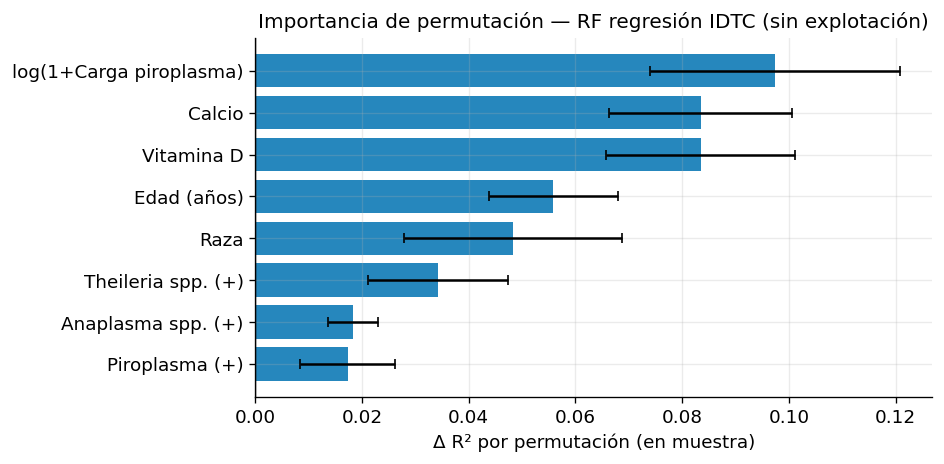

In [3]:
print("Paso 1: Ajustando RF regresión completo para ranking de importancia...")
full_pipe = make_pipe_f(tb.MODEL_FEATURES).fit(X_all, y)
print(f"OOB Score (R², en muestra): {full_pipe.named_steps['clf'].oob_score_:.3f}")

pi = permutation_importance(
    full_pipe, X_all, y,
    scoring="r2",
    n_repeats=50,
    random_state=tb.SEED,
    n_jobs=-1,
)
imp_df = pd.DataFrame({
    "feature":  tb.MODEL_FEATURES,
    "imp_mean": pi.importances_mean,
    "imp_std":  pi.importances_std,
}).sort_values("imp_mean", ascending=False).reset_index(drop=True)
imp_df["pretty"] = imp_df.feature.map(lambda f: tb.PRETTY.get(f, f))

print("\nRanking importancia de permutación (R², sin explotación):")
print(imp_df[["pretty", "imp_mean", "imp_std"]].round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
order = imp_df.sort_values("imp_mean")
ax.barh(order.pretty, order.imp_mean, xerr=order.imp_std, color=PALETTE[0], capsize=3, alpha=0.85)
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("Δ R² por permutación (en muestra)")
ax.set_title("Importancia de permutación — RF regresión IDTC (sin explotación)")
plt.tight_layout(); plt.savefig("figures/fig_2f_perm_importance_full.png"); plt.show()

In [4]:
elim_order = imp_df.sort_values("imp_mean", ascending=True)["feature"].tolist()
print(f"Orden de eliminación: {elim_order}\n")
print("Paso 2: Eliminación hacia atrás (CV por animal, puede tardar 1-2 min)...\n")

current_features = tb.MODEL_FEATURES.copy()
history = []

m0, s0 = cv_animal_metrics_f(current_features, X_all, y, cv=CV_SEL_F)
history.append({"n": len(current_features), "features": current_features.copy(),
                "removed": "—(baseline)", "mean": m0, "std": s0})
print(f"  {len(current_features):2d} features [baseline] Spearman={m0:.3f}±{s0:.3f}")

for feat in elim_order:
    if feat not in current_features or len(current_features) <= 1:
        break
    test_feats = [f for f in current_features if f != feat]
    m, s = cv_animal_metrics_f(test_feats, X_all, y, cv=CV_SEL_F)
    history.append({"n": len(test_feats), "features": test_feats.copy(),
                    "removed": feat, "mean": m, "std": s})
    print(f"  {len(test_feats):2d} features [-{feat:20s}] Spearman={m:.3f}±{s:.3f}  Δ={m-m0:+.3f}")
    current_features = test_feats

hist_df = pd.DataFrame(history)

Orden de eliminación: ['PIROPLASMA', 'ANAPLASMA', 'THEILERIA', 'RAZA2', 'EDAD', 'VITAMINA_D', 'CALCIO', 'PIROPLASMA_Q_log']

Paso 2: Eliminación hacia atrás (CV por animal, puede tardar 1-2 min)...

   8 features [baseline] Spearman=-0.009±0.165
   7 features [-PIROPLASMA          ] Spearman=-0.011±0.149  Δ=-0.002
   6 features [-ANAPLASMA           ] Spearman=-0.017±0.118  Δ=-0.008
   5 features [-THEILERIA           ] Spearman=-0.030±0.127  Δ=-0.021
   4 features [-RAZA2               ] Spearman=-0.081±0.162  Δ=-0.072
   3 features [-EDAD                ] Spearman=-0.082±0.161  Δ=-0.073
   2 features [-VITAMINA_D          ] Spearman=-0.047±0.162  Δ=-0.038
   1 features [-CALCIO              ] Spearman=0.044±0.194  Δ=+0.053


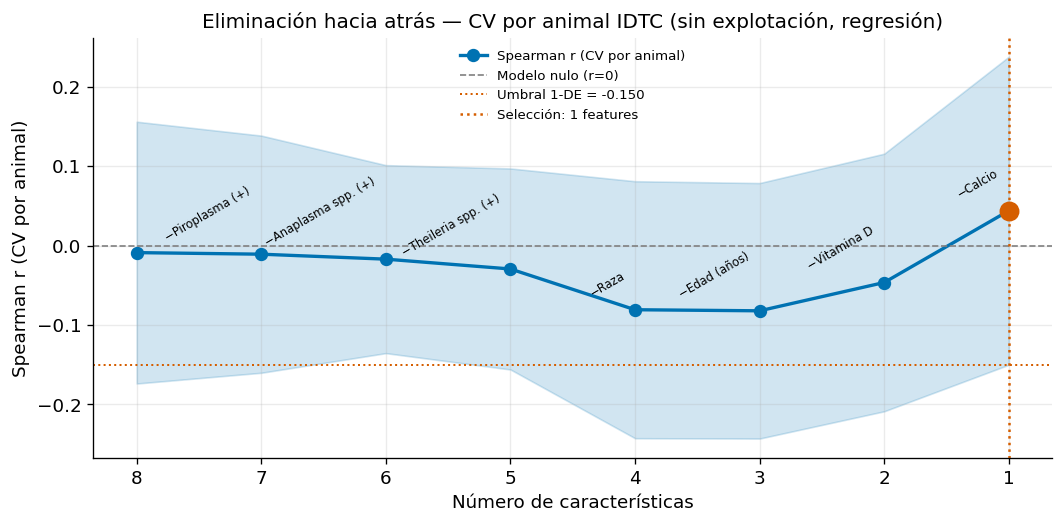


Features SELECCIONADOS (1): ['PIROPLASMA_Q_log']


In [5]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(hist_df.n, hist_df["mean"], "o-", color=PALETTE[0], lw=2, ms=7,
        label="Spearman r (CV por animal)")
ax.fill_between(hist_df.n,
                hist_df["mean"] - hist_df["std"],
                hist_df["mean"] + hist_df["std"], alpha=0.18, color=PALETTE[0])
ax.axhline(0, ls="--", color="grey", lw=1, label="Modelo nulo (r=0)")

best_idx     = hist_df["mean"].idxmax()
best_mu      = hist_df["mean"].max()
best_sd      = hist_df.loc[best_idx, "std"]
threshold    = best_mu - best_sd
parsimonious = hist_df[hist_df["mean"] >= threshold].sort_values("n").iloc[0]

ax.axhline(threshold, ls=":", color=PALETTE[1], lw=1.2,
           label=f"Umbral 1-DE = {threshold:.3f}")
ax.axvline(parsimonious.n, color=PALETTE[1], ls=":", lw=1.5,
           label=f"Selección: {int(parsimonious.n)} features")
ax.scatter([parsimonious.n], [parsimonious["mean"]], color=PALETTE[1], s=120, zorder=5)

for _, row in hist_df.iterrows():
    label = tb.PRETTY.get(row.removed, row.removed) if row.removed != "—(baseline)" else ""
    if label:
        ax.annotate(f"−{label}", (row.n, row["mean"]),
                    textcoords="offset points", xytext=(-5, 8),
                    fontsize=7, ha="right", rotation=30)

ax.set_xlabel("Número de características")
ax.set_ylabel("Spearman r (CV por animal)")
ax.set_title("Eliminación hacia atrás — CV por animal IDTC (sin explotación, regresión)")
ax.legend(fontsize=8); ax.invert_xaxis()
plt.tight_layout(); plt.savefig("figures/fig_2f_feature_selection_curve.png"); plt.show()

SELECTED_F = list(parsimonious.features)
print(f"\nFeatures SELECCIONADOS ({len(SELECTED_F)}): {SELECTED_F}")

In [6]:
print("Calculando R² para cada subconjunto de hist_df (≈1 min)...")
r2_means, r2_stds = [], []
for _, row in hist_df.iterrows():
    detailed_tmp = cv_animal_metrics_f(row["features"], X_all, y, cv=CV_SEL_F, detailed=True)
    r2_means.append(detailed_tmp.r2.mean())
    r2_stds.append(detailed_tmp.r2.std())
    print(f"  {int(row.n):2d} features [-{row['removed']:20s}] R²={r2_means[-1]:.3f}±{r2_stds[-1]:.3f}")

hist_df = hist_df.assign(r2_mean=r2_means, r2_std=r2_stds)
print("\nhist_df actualizado con columnas r2_mean / r2_std.")

Calculando R² para cada subconjunto de hist_df (≈1 min)...
   8 features [-—(baseline)         ] R²=-0.185±0.292
   7 features [-PIROPLASMA          ] R²=-0.177±0.262
   6 features [-ANAPLASMA           ] R²=-0.176±0.251
   5 features [-THEILERIA           ] R²=-0.169±0.243
   4 features [-RAZA2               ] R²=-0.228±0.280
   3 features [-EDAD                ] R²=-0.222±0.243
   2 features [-VITAMINA_D          ] R²=-0.188±0.218
   1 features [-CALCIO              ] R²=-0.227±0.306

hist_df actualizado con columnas r2_mean / r2_std.


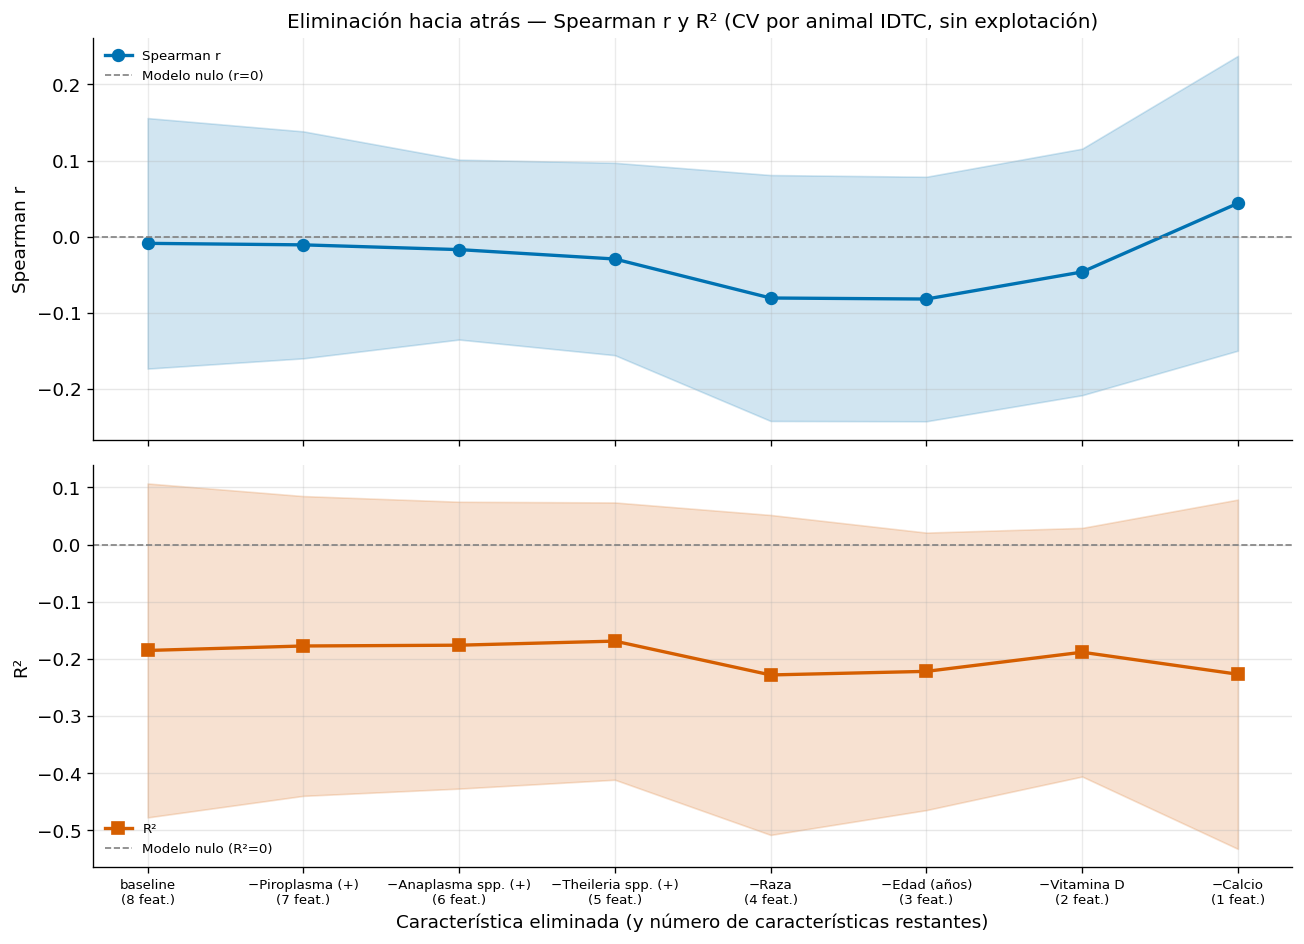

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

x      = np.arange(len(hist_df))
labels = []
for _, row in hist_df.iterrows():
    if row["removed"] == "—(baseline)":
        lbl = f"baseline\n({int(row.n)} feat.)"
    else:
        pretty = tb.PRETTY.get(row["removed"], row["removed"])
        lbl = f"−{pretty}\n({int(row.n)} feat.)"
    labels.append(lbl)

# --- Spearman r ---
ax1 = axes[0]
ax1.plot(x, hist_df["mean"], "o-", color=PALETTE[0], lw=2, ms=7, label="Spearman r")
ax1.fill_between(x,
                 hist_df["mean"] - hist_df["std"],
                 hist_df["mean"] + hist_df["std"],
                 alpha=0.18, color=PALETTE[0])
ax1.axhline(0, ls="--", color="grey", lw=1, label="Modelo nulo (r=0)")
ax1.set_ylabel("Spearman r")
ax1.legend(fontsize=8)
ax1.set_title("Eliminación hacia atrás — Spearman r y R² (CV por animal IDTC, sin explotación)")
ax1.grid(axis="y", alpha=0.3)

# --- R² ---
ax2 = axes[1]
ax2.plot(x, hist_df["r2_mean"], "s-", color=PALETTE[1], lw=2, ms=7, label="R²")
ax2.fill_between(x,
                 hist_df["r2_mean"] - hist_df["r2_std"],
                 hist_df["r2_mean"] + hist_df["r2_std"],
                 alpha=0.18, color=PALETTE[1])
ax2.axhline(0, ls="--", color="grey", lw=1, label="Modelo nulo (R²=0)")
ax2.set_ylabel("R²")
ax2.legend(fontsize=8)
ax2.grid(axis="y", alpha=0.3)

ax2.set_xticks(x)
ax2.set_xticklabels(labels, fontsize=8, ha="center")
ax2.set_xlabel("Característica eliminada (y número de características restantes)")

plt.tight_layout()
plt.savefig("figures/fig_2f_feature_selection_metrics.png", bbox_inches="tight")
plt.show()

## 4. Evaluación del modelo final (CV por animal, 5×10)

Features (3): ['VITAMINA_D', 'CALCIO', 'PIROPLASMA_Q_log']

Métricas CV por animal (5×10, sin explotación) — IDTC regresión:
  Spearman = -0.047 ± 0.199
  R²       = -0.230 ± 0.325
  RMSE     = 6.335 ± 1.009


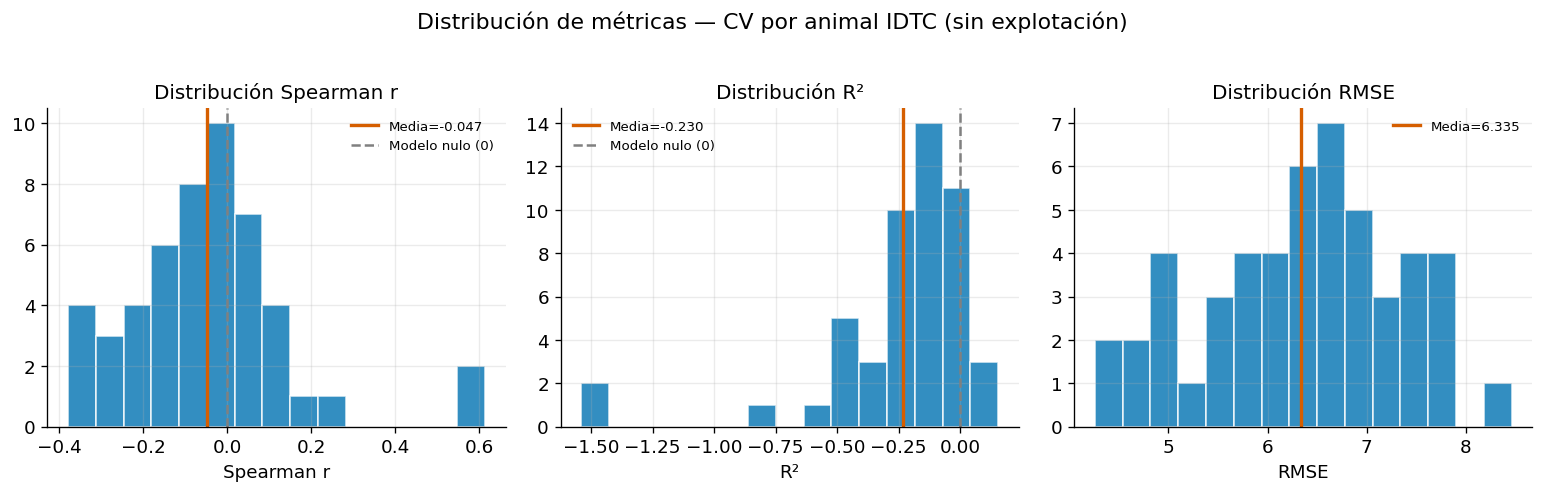

In [18]:
# Ajustar manualmente si se desea un subconjunto específico;
# por defecto se usa el seleccionado por el criterio 1-DE
SELECTED_F = ["VITAMINA_D", "CALCIO", 'PIROPLASMA_Q_log' ]  # ejemplo

Xs = X_all[SELECTED_F].copy()
print(f"Features ({len(SELECTED_F)}): {SELECTED_F}\n")

detailed_df = cv_animal_metrics_f(
    SELECTED_F, X_all, y, cv=CV_OUTER_F, detailed=True, n_estimators=3000
)
m = detailed_df.mean(); s = detailed_df.std()

print("Métricas CV por animal (5×10, sin explotación) — IDTC regresión:")
print(f"  Spearman = {m.spearman:.3f} ± {s.spearman:.3f}")
print(f"  R²       = {m.r2:.3f} ± {s.r2:.3f}")
print(f"  RMSE     = {m.rmse:.3f} ± {s.rmse:.3f}")

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col, title in zip(axes,
                          ["spearman", "r2", "rmse"],
                          ["Spearman r", "R²", "RMSE"]):
    ax.hist(detailed_df[col].dropna(), bins=15, color=PALETTE[0], alpha=0.8, edgecolor="white")
    ax.axvline(detailed_df[col].mean(), color=PALETTE[1], lw=2,
               label=f"Media={detailed_df[col].mean():.3f}")
    if col in ("spearman", "r2"):
        ax.axvline(0, color="grey", ls="--", lw=1.5, label="Modelo nulo (0)")
    ax.set_xlabel(title); ax.set_title(f"Distribución {title}"); ax.legend(fontsize=8)
plt.suptitle("Distribución de métricas — CV por animal IDTC (sin explotación)", y=1.02)
plt.tight_layout()
plt.savefig("figures/fig_2f_metrics_dist.png", bbox_inches="tight")
plt.show()

## 5. Interpretabilidad global — SHAP

Este análisis muestra la importancia de los biomarcadores **en ausencia de información
de granja** para predecir la intensidad IDTC. Cualquier señal detectada aquí es
potencialmente transferible a nuevas granjas.

In [9]:
FINAL_F = make_pipe_f(SELECTED_F, n_estimators=500).fit(Xs, y)
print(f"OOB Score (R², en muestra): {FINAL_F.named_steps['clf'].oob_score_:.3f}")

prep_f  = FINAL_F.named_steps["prep"]
clf_f   = FINAL_F.named_steps["clf"]
Xt_f    = prep_f.transform(Xs)
names_f = list(prep_f.get_feature_names_out())

explainer_f = shap.TreeExplainer(clf_f)
sv_f = np.asarray(explainer_f.shap_values(Xt_f))
if sv_f.ndim == 3:          # SHAP nuevo puede añadir dimensión extra en regresión
    sv_f = sv_f[:, :, 0]

# expected_value puede ser array 1D en versiones recientes de SHAP
exp_val_f = float(np.asarray(explainer_f.expected_value).ravel()[0])

print(f"Features tras preprocesamiento : {names_f}")
print(f"SHAP values shape              : {sv_f.shape}")
print(f"Expected value (media predicha): {exp_val_f:.4f}")


OOB Score (R², en muestra): -0.112
Features tras preprocesamiento : ['VITAMINA_D', 'CALCIO', 'PIROPLASMA_Q_log']
SHAP values shape              : (103, 3)
Expected value (media predicha): 11.3529


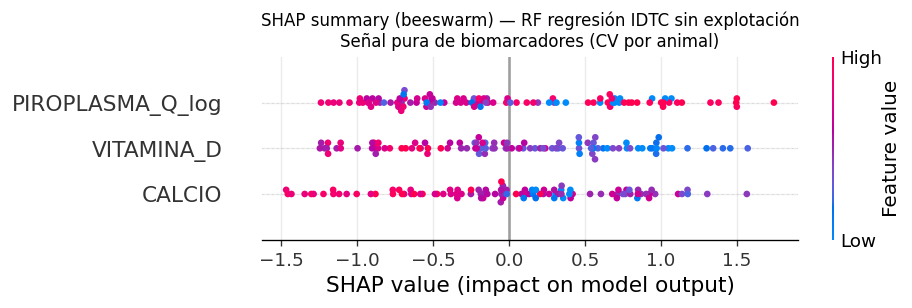

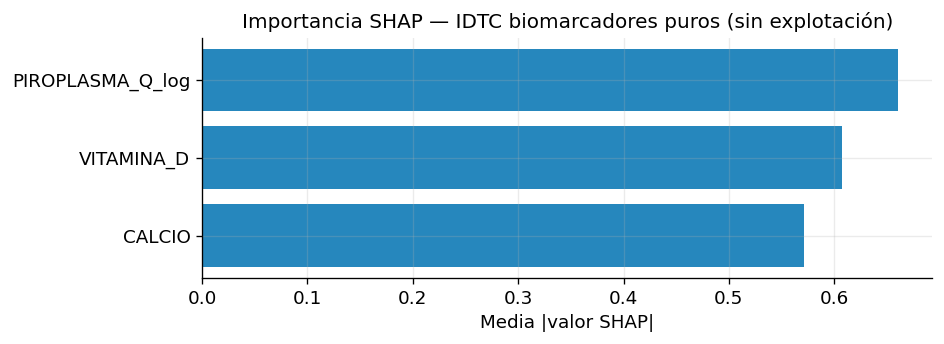

In [10]:
plt.figure(figsize=(9, max(4, 0.5 * len(names_f))))
shap.summary_plot(sv_f, Xt_f, feature_names=names_f, show=False, max_display=len(names_f))
plt.title("SHAP summary (beeswarm) — RF regresión IDTC sin explotación\n"
          "Señal pura de biomarcadores (CV por animal)", fontsize=10)
plt.tight_layout()
plt.savefig("figures/fig_2f_shap_summary.png", bbox_inches="tight")
plt.show()

# Importancia media |SHAP|
mean_abs_f = np.abs(sv_f).mean(0)
si_f = pd.DataFrame({"feature": names_f, "mean_abs": mean_abs_f}).sort_values("mean_abs")
fig, ax = plt.subplots(figsize=(8, max(3, 0.4 * len(names_f))))
ax.barh(si_f.feature, si_f.mean_abs, color=PALETTE[0], alpha=0.85)
ax.set_xlabel("Media |valor SHAP|")
ax.set_title("Importancia SHAP — IDTC biomarcadores puros (sin explotación)")
plt.tight_layout()
plt.savefig("figures/fig_2f_shap_importance.png")
plt.show()

In [11]:
# Force plot global: todos los animales ordenados por predicción
shap.initjs()

order = np.argsort(FINAL_F.predict(Xs))
fp = shap.force_plot(
    exp_val_f,
    sv_f[order, :],
    Xt_f[order, :] if hasattr(Xt_f, "__getitem__") else Xt_f[order],
    feature_names=names_f,
)
shap.save_html("figures/fig_2f_shap_force_plot_global.html", fp)
display(fp)

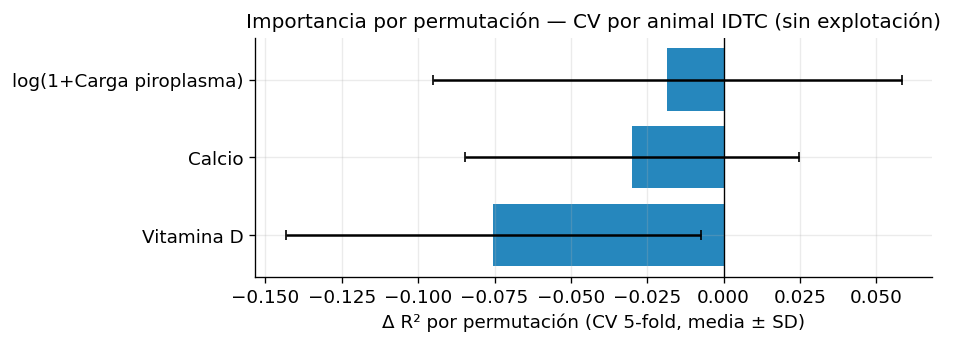

Estabilidad Spearman entre folds: -0.100


In [12]:
# Importancia por permutación — estabilidad
from scipy.stats import spearmanr

imp_runs_f = []
cv_stab = KFold(n_splits=5, shuffle=True, random_state=tb.SEED)
for tr, te in cv_stab.split(Xs, y):
    pf = clone(make_pipe_f(SELECTED_F)).fit(Xs.iloc[tr], y[tr])
    pi_f = permutation_importance(pf, Xs.iloc[te], y[te],
                                  scoring="r2", n_repeats=20,
                                  random_state=tb.SEED)
    imp_runs_f.append(pd.Series(pi_f.importances_mean, index=SELECTED_F))

imp_mat_f = pd.concat(imp_runs_f, axis=1)
imp_ord_f = imp_mat_f.mean(axis=1).sort_values().index

R = imp_mat_f.fillna(0)
cors = [spearmanr(R.iloc[:, i], R.iloc[:, j]).correlation
        for i in range(R.shape[1]) for j in range(i + 1, R.shape[1])]

fig, ax = plt.subplots(figsize=(8, max(3, 0.45 * len(SELECTED_F))))
ax.barh([tb.PRETTY.get(f, f) for f in imp_ord_f],
        imp_mat_f.mean(axis=1)[imp_ord_f],
        xerr=imp_mat_f.std(axis=1)[imp_ord_f],
        color=PALETTE[0], capsize=3, alpha=0.85)
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("Δ R² por permutación (CV 5-fold, media ± SD)")
ax.set_title("Importancia por permutación — CV por animal IDTC (sin explotación)")
plt.tight_layout()
plt.savefig("figures/fig_2f_perm_importance_cv.png")
plt.show()
print(f"Estabilidad Spearman entre folds: {np.nanmean(cors):.3f}")

## 6. Partial Dependence Plots + ICE

Features continuas para PDP/ICE: ['VITAMINA_D', 'CALCIO', 'PIROPLASMA_Q_log']


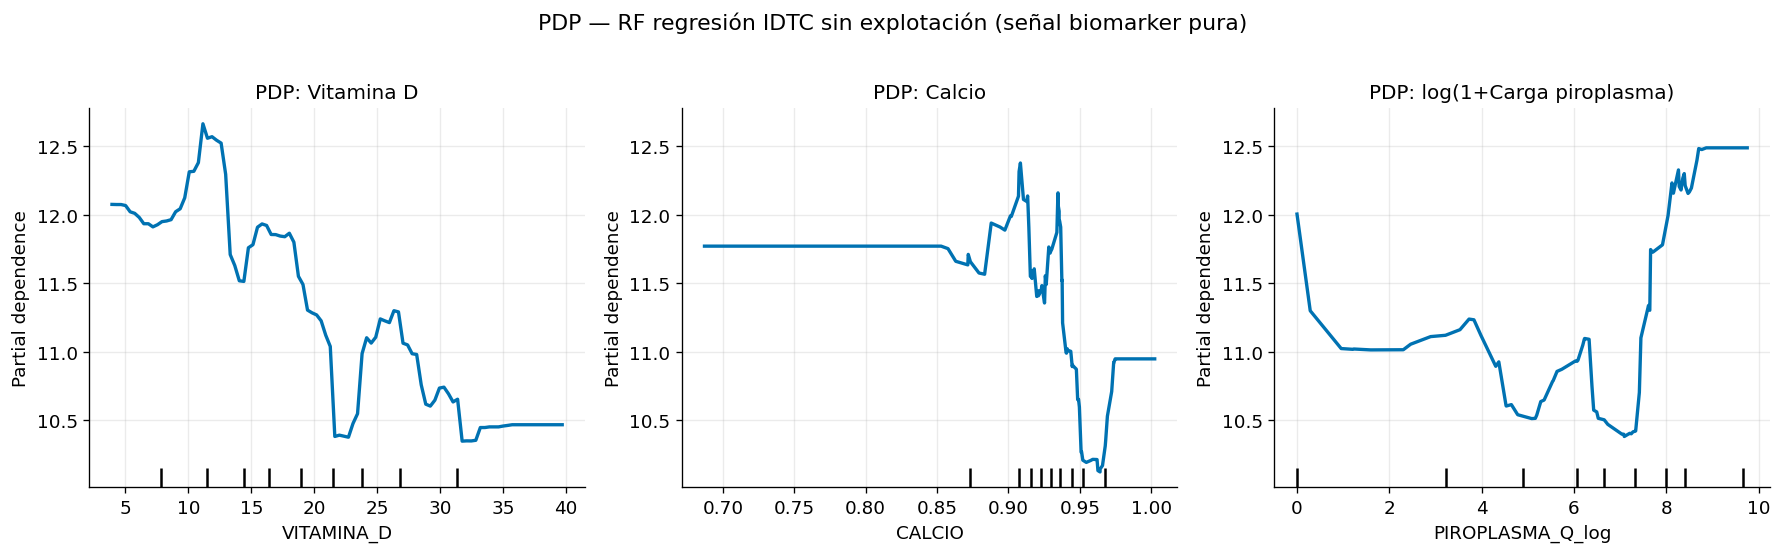

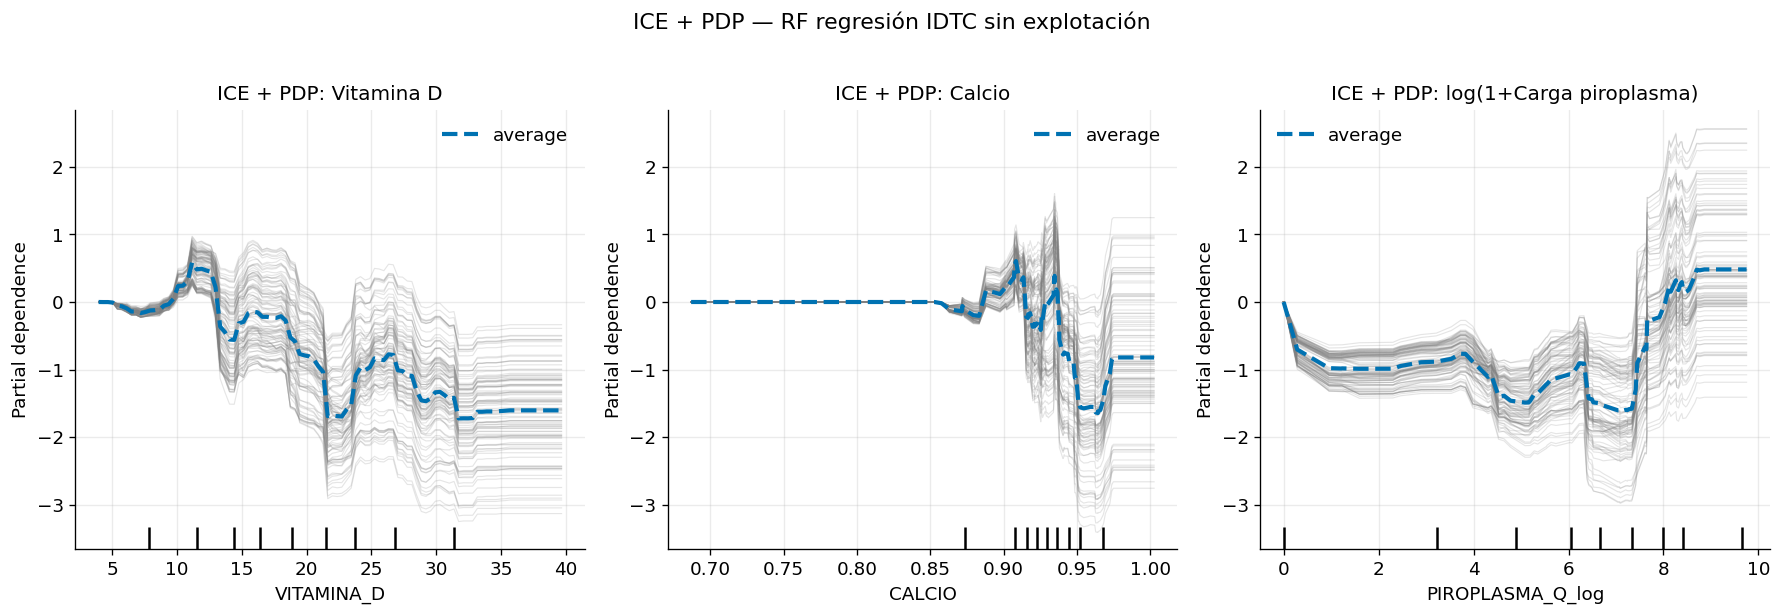

In [13]:
CONT_F = [f for f in SELECTED_F if f in tb.NUM_FEATURES and Xs[f].nunique() > 5]
if not CONT_F:
    CONT_F = [f for f in SELECTED_F if f in tb.NUM_FEATURES]

print(f"Features continuas para PDP/ICE: {CONT_F}")
if CONT_F:
    n_c = len(CONT_F)
    # PDP
    fig, axes = plt.subplots(1, n_c, figsize=(5 * n_c, 4.5))
    if n_c == 1: axes = [axes]
    PartialDependenceDisplay.from_estimator(
        FINAL_F, Xs, CONT_F, kind="average",
        ax=axes, line_kw={"color": PALETTE[0], "lw": 2}
    )
    for ax, f in zip(axes, CONT_F):
        ax.set_title(f"PDP: {tb.PRETTY.get(f, f)}")
    plt.suptitle("PDP — RF regresión IDTC sin explotación (señal biomarker pura)", y=1.02)
    plt.tight_layout()
    plt.savefig("figures/fig_2f_pdp.png", bbox_inches="tight")
    plt.show()

    # ICE + PDP
    fig, axes = plt.subplots(1, n_c, figsize=(5 * n_c, 5))
    if n_c == 1: axes = [axes]
    PartialDependenceDisplay.from_estimator(
        FINAL_F, Xs, CONT_F, kind="both",
        ax=axes,
        ice_lines_kw={"color": "grey", "alpha": 0.2, "lw": 0.7},
        pd_line_kw={"color": PALETTE[0], "lw": 2.5},
        centered=True
    )
    for ax, f in zip(axes, CONT_F):
        ax.set_title(f"ICE + PDP: {tb.PRETTY.get(f, f)}")
    plt.suptitle("ICE + PDP — RF regresión IDTC sin explotación", y=1.02)
    plt.tight_layout()
    plt.savefig("figures/fig_2f_ice.png", bbox_inches="tight")
    plt.show()

## 7. Accumulated Local Effects (ALE)

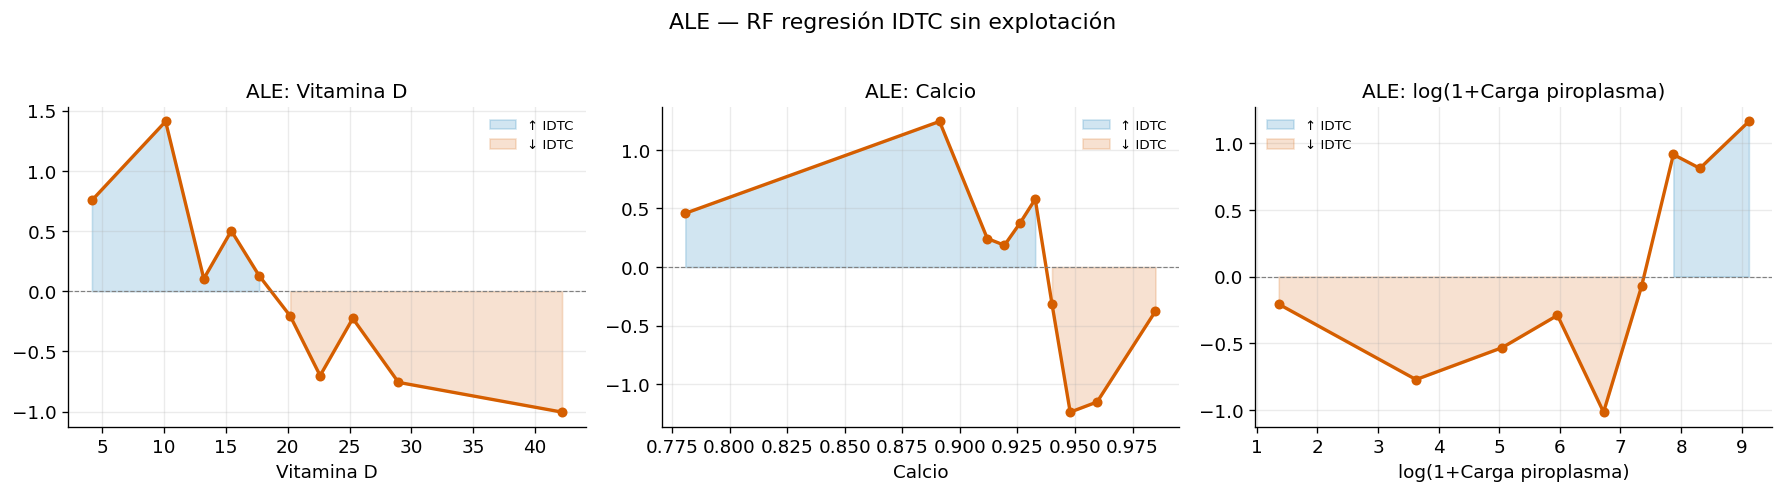

In [14]:
def ale_1d_reg(model, X, feat, bins=10):
    """ALE 1D para regresión: efecto acumulado local sobre la predicción continua."""
    x = X[feat].dropna().values
    q = np.quantile(x, np.linspace(0, 1, bins + 1)); q = np.unique(q)
    if len(q) < 3: return np.array([]), np.array([])
    eff, Xc = [], X.copy()
    for i in range(len(q) - 1):
        mask = (X[feat] >= q[i]) & (X[feat] <= q[i + 1])
        if mask.sum() == 0: eff.append(0.0); continue
        lo = Xc.loc[mask].copy(); lo[feat] = q[i]
        hi = Xc.loc[mask].copy(); hi[feat] = q[i + 1]
        eff.append((model.predict(hi) - model.predict(lo)).mean())
    ale = np.cumsum(eff); ale -= ale.mean()
    return (q[:-1] + q[1:]) / 2, ale

if CONT_F:
    n_c = len(CONT_F)
    fig, axes = plt.subplots(1, n_c, figsize=(5 * n_c, 4))
    if n_c == 1: axes = [axes]
    for ax, feat in zip(axes, CONT_F):
        cx, ale = ale_1d_reg(FINAL_F, Xs, feat)
        if len(cx) == 0:
            ax.set_title(f"ALE: {tb.PRETTY.get(feat, feat)}\n(insuf.)")
            continue
        ax.plot(cx, ale, "o-", color=PALETTE[1], lw=2, ms=5)
        ax.axhline(0, color="grey", lw=0.7, ls="--")
        ax.fill_between(cx, 0, ale, where=(ale > 0), alpha=0.18, color=PALETTE[0],
                        label="↑ IDTC")
        ax.fill_between(cx, 0, ale, where=(ale < 0), alpha=0.18, color=PALETTE[1],
                        label="↓ IDTC")
        ax.set_title(f"ALE: {tb.PRETTY.get(feat, feat)}")
        ax.set_xlabel(tb.PRETTY.get(feat, feat))
        ax.legend(fontsize=8)
    plt.suptitle("ALE — RF regresión IDTC sin explotación", y=1.02)
    plt.tight_layout()
    plt.savefig("figures/fig_2f_ale.png", bbox_inches="tight")
    plt.show()

## 8. SHAP waterfall — interpretabilidad local

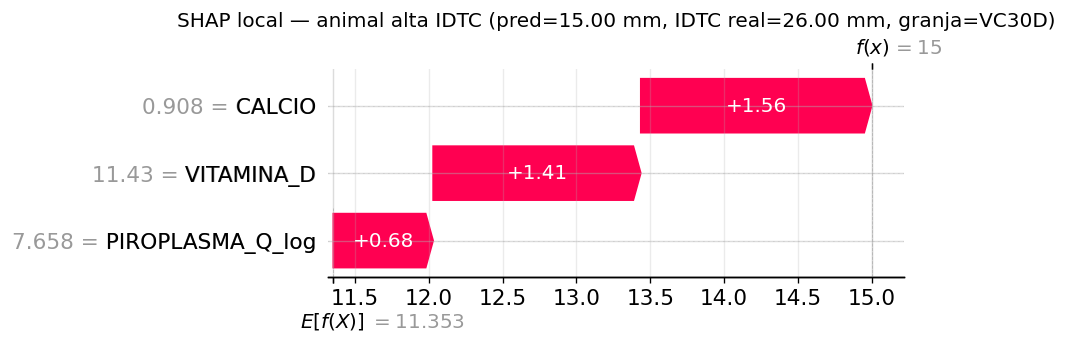

Animal 24: pred=15.00, IDTC real=26.00, granja=VC30D


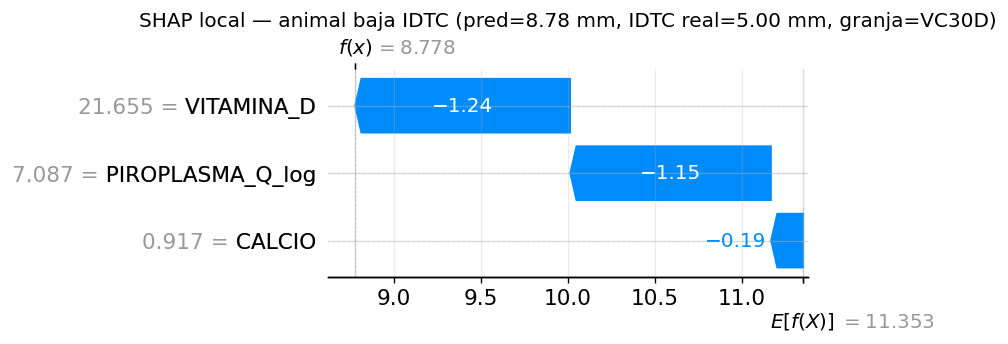

Animal 32: pred=8.78, IDTC real=5.00, granja=VC30D


In [15]:
pred_all_f = FINAL_F.predict(Xs)
idx_high   = int(np.argmax(pred_all_f))   # animal con IDTC predicha más alta
idx_low    = int(np.argmin(pred_all_f))   # animal con IDTC predicha más baja

shap_exp_f = shap.Explanation(
    values=sv_f, base_values=exp_val_f,
    data=Xt_f, feature_names=names_f
)

for tag, idx in [("alta_IDTC", idx_high), ("baja_IDTC", idx_low)]:
    farm_ref = g[idx]
    fig, _ = plt.subplots(figsize=(9, 4))
    shap.plots.waterfall(shap_exp_f[idx], max_display=len(names_f), show=False)
    plt.title(
        f"SHAP local — animal {tag.replace('_', ' ')} "
        f"(pred={pred_all_f[idx]:.2f} mm, IDTC real={y[idx]:.2f} mm, granja={farm_ref})"
    )
    plt.tight_layout()
    plt.savefig(f"figures/fig_2f_waterfall_{tag}.png", bbox_inches="tight")
    plt.show()
    print(f"Animal {idx}: pred={pred_all_f[idx]:.2f}, IDTC real={y[idx]:.2f}, granja={farm_ref}")

## 9. Contrafactuales

In [16]:
def find_cf_reg(model, row_dict, feat, lo, hi, threshold, direction="above", n=500):
    """Halla el valor mínimo del feature que lleva la predicción por encima/debajo de threshold."""
    for v in np.linspace(lo, hi, n):
        r = dict(row_dict); r[feat] = v
        pred = model.predict(pd.DataFrame([r]))[0]
        if direction == "above" and pred >= threshold:
            return v, pred
        if direction == "below" and pred <= threshold:
            return v, pred
    return None, None

high_row = Xs.iloc[idx_high].copy()
low_row  = Xs.iloc[idx_low].copy()

# Umbral de referencia: media de IDTC observada
threshold_idtc = float(y.mean())
print(f"Umbral de referencia IDTC = {threshold_idtc:.2f} mm (media observada)")

print("=" * 60)
print("CONTRAFACTUALES — solo con biomarcadores (IDTC regresión)")
print("=" * 60)
for tag, row, direction in [
    ("ALTA IDTC predicha",  high_row, "below"),
    ("BAJA IDTC predicha",  low_row,  "above"),
]:
    pred = FINAL_F.predict(pd.DataFrame([row]))[0]
    print(f"\nAnimal {tag} (pred={pred:.2f} mm), objetivo → {'< ' if direction=='below' else '≥ '}{threshold_idtc:.2f} mm")
    for feat in CONT_F:
        lo_v, hi_v = float(Xs[feat].min()), float(Xs[feat].max())
        cf_v, cf_pred = find_cf_reg(
            FINAL_F, row.to_dict(), feat, lo_v, hi_v,
            threshold_idtc, direction=direction
        )
        cur = row[feat]
        if cf_v is not None:
            print(f"  {tb.PRETTY.get(feat, feat):30s}: actual={cur:.2f} → cf={cf_v:.2f} "
                  f"(Δ={cf_v - cur:+.2f}, pred_cf={cf_pred:.2f})")
        else:
            print(f"  {tb.PRETTY.get(feat, feat):30s}: actual={cur:.2f} → no alcanzable en rango observado")

Umbral de referencia IDTC = 11.38 mm (media observada)
CONTRAFACTUALES — solo con biomarcadores (IDTC regresión)

Animal ALTA IDTC predicha (pred=15.00 mm), objetivo → < 11.38 mm
  Vitamina D                    : actual=11.43 → no alcanzable en rango observado
  Calcio                        : actual=0.91 → cf=0.95 (Δ=+0.04, pred_cf=11.23)
  log(1+Carga piroplasma)       : actual=7.66 → no alcanzable en rango observado

Animal BAJA IDTC predicha (pred=8.78 mm), objetivo → ≥ 11.38 mm
  Vitamina D                    : actual=21.65 → cf=10.84 (Δ=-10.81, pred_cf=11.46)
  Calcio                        : actual=0.92 → no alcanzable en rango observado
  log(1+Carga piroplasma)       : actual=7.09 → cf=8.09 (Δ=+1.00, pred_cf=11.46)


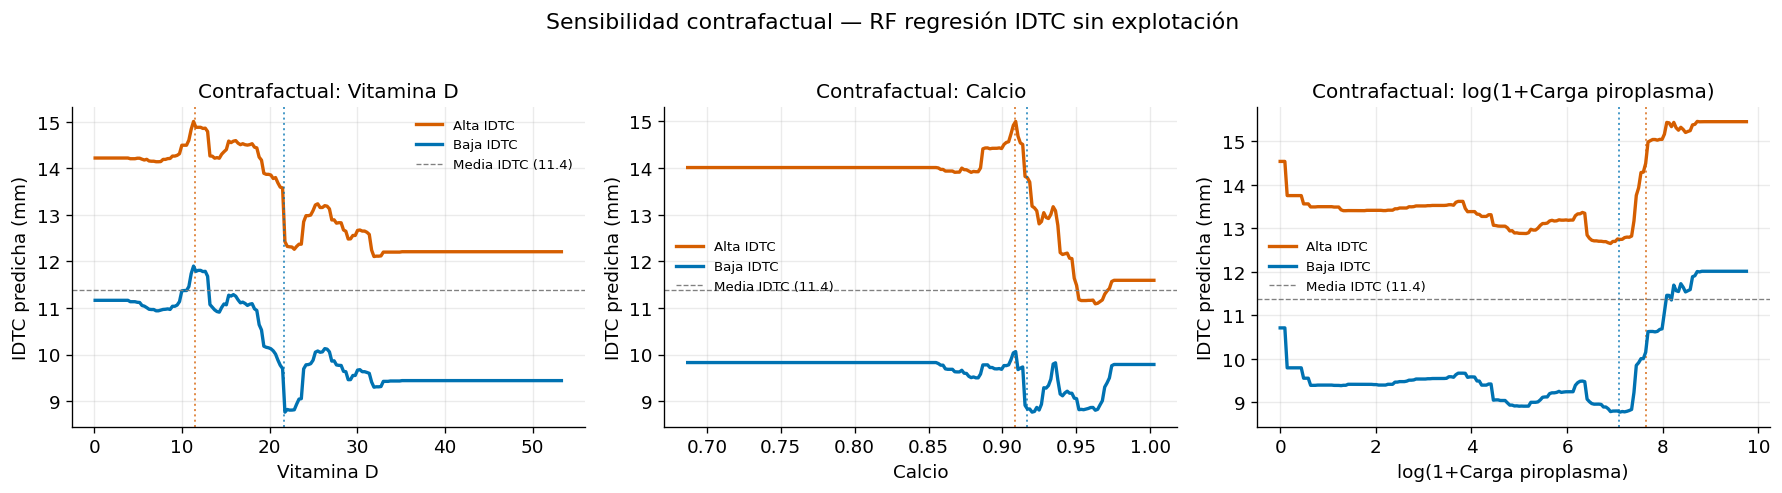

In [17]:
if CONT_F:
    n_c = len(CONT_F)
    fig, axes = plt.subplots(1, n_c, figsize=(5 * n_c, 4))
    if n_c == 1: axes = [axes]
    for ax, feat in zip(axes, CONT_F):
        lo_v, hi_v = float(Xs[feat].min()), float(Xs[feat].max())
        grid = np.linspace(lo_v, hi_v, 200)
        for tag, row, color in [
            ("Alta IDTC", high_row, PALETTE[1]),
            ("Baja IDTC", low_row,  PALETTE[0]),
        ]:
            preds_grid = [
                FINAL_F.predict(pd.DataFrame([{**row.to_dict(), feat: v}]))[0]
                for v in grid
            ]
            ax.plot(grid, preds_grid, color=color, lw=2, label=tag)
            ax.axvline(row[feat], color=color, ls=":", lw=1.2, alpha=0.7)
        ax.axhline(threshold_idtc, color="grey", ls="--", lw=0.8,
                   label=f"Media IDTC ({threshold_idtc:.1f})")
        ax.set_xlabel(tb.PRETTY.get(feat, feat))
        ax.set_ylabel("IDTC predicha (mm)")
        ax.set_title(f"Contrafactual: {tb.PRETTY.get(feat, feat)}")
        ax.legend(fontsize=8)
    plt.suptitle("Sensibilidad contrafactual — RF regresión IDTC sin explotación", y=1.02)
    plt.tight_layout()
    plt.savefig("figures/fig_2f_cf_curves.png", bbox_inches="tight")
    plt.show()

## 10. Síntesis

### Tabla de métricas

| Métrica | Valor (media ± SD, 5×10 CV) |
|---|---|
| Spearman r | — |
| R² | — |
| RMSE (mm) | — |

### Guía de interpretación

- **Si Spearman r > 0.3 y R² > 0.1:** los biomarcadores tienen señal real para predecir la
  intensidad IDTC, incluso sin información de la granja.

- **Si Spearman r ≈ 0 y R² ≈ 0:** no existe señal predictiva robusta en estos biomarcadores
  para la intensidad IDTC. El outcome puede estar dominado por variabilidad entre granjas
  (confusión por explotación) o por factores no medidos.

- **Comparar con Notebook 2e (Score_lesional):** si Score_lesional es predecible pero IDTC
  no, sugiere que la reacción inmunológica cutánea (IDTC) está menos vinculada a los
  biomarcadores sistémicos que la carga lesional.

### Implicaciones clínicas

La IDTC es la prueba oficial de diagnóstico de TB bovina en campo. Predecir su intensidad
a partir de biomarcadores de laboratorio abriría la posibilidad de:
1. Identificar animales con reacción esperada baja (falsos negativos potenciales) antes de
   la prueba.
2. Priorizar animales para pruebas confirmatorias en función de la intensidad predicha.
3. Comprender los mecanismos biológicos que modulan la respuesta inmune cutánea en TB bovina.